# Sales Data Quality Audit & Business Performance Analysis for a Retail Company

In [1]:
import pandas as pd

In [2]:
# Data Loading
sales_data = pd.read_csv("C:\\Users\\HP\\Downloads\\messy_sales_data.csv")

### Data Inspection

In [3]:

sales_data.head()


,OrderID,OrderDate,Region,Category,Sales,Profit,CustomerID
0,ORD4315,7/28/2023,USA,Office Supplies,-499.13,123.26,CUST222
1,ORD1351,12/15/2022,EU,Technology,325.97,-88.16,CUST100
2,ORD1957,4/28/2022,Asia,Technology,9.84,-0.73,CUST100
3,ORD2310,2/11/2022,EU,Office Supplies,389.42,-104.29,CUST100
4,ORD1092,7/7/2022,US,Furniture,301.93,64.88,NaN


In [4]:
sales_data.dtypes

OrderID        object
OrderDate      object
Region         object
Category       object
Sales         float64
Profit        float64
CustomerID     object
dtype: object

In [5]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8200 entries, 0 to 8199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     8200 non-null   object 
 1   OrderDate   8200 non-null   object 
 2   Region      7786 non-null   object 
 3   Category    8200 non-null   object 
 4   Sales       7790 non-null   float64
 5   Profit      8200 non-null   float64
 6   CustomerID  7790 non-null   object 
dtypes: float64(2), object(5)
memory usage: 448.6+ KB


In [6]:
sales_data.describe()

,Sales,Profit
count,7790.000000,8200.000000
mean,246.806063,-1.025563
std,160.299478,50.585461
min,-499.130000,-145.600000
25%,128.145000,-31.212500
50%,255.030000,-0.490000
75%,375.775000,28.072500
max,499.950000,147.300000


In [7]:
sales_data.duplicated().sum()

193

### Data Cleaning

In [8]:
sales_data.drop_duplicates()

,OrderID,OrderDate,Region,Category,Sales,Profit,CustomerID
0,ORD4315,7/28/2023,USA,Office Supplies,-499.13,123.26,CUST222
1,ORD1351,12/15/2022,EU,Technology,325.97,-88.16,CUST100
2,ORD1957,4/28/2022,Asia,Technology,9.84,-0.73,CUST100
3,ORD2310,2/11/2022,EU,Office Supplies,389.42,-104.29,CUST100
4,ORD1092,7/7/2022,US,Furniture,301.93,64.88,NaN
...,...,...,...,...,...,...,...
8194,ORD8883,5/27/2022,asia,Office Supplies,196.29,-47.77,NaN
8195,ORD8721,11/28/2022,USA,Technology,NaN,-61.31,CUST695
8196,ORD8985,1/31/2022,USA,Furniture,NaN,-37.58,CUST849
8197,ORD8989,9/28/2022,Europe,Office Supplies,129.70,-30.25,NaN


In [9]:
sales_data.isnull().sum()

OrderID         0
OrderDate       0
Region        414
Category        0
Sales         410
Profit          0
CustomerID    410
dtype: int64

In [10]:
sales_data['Region'] = sales_data['Region'].str.strip().str.title()

region_map = {
    'Us': 'USA',        # 'US' or 'us' → 'USA'
    'Usa': 'USA',       # 'USA' or 'usa' → 'USA'
    'EU': 'Europe',     # 'Eu' or 'eu' → 'Europe'
    'Eu': 'Europe',     # 'Eu' or 'eu' → 'Europe'
    'Europe': 'Europe', # keep Europe as Europe
    'asia': 'Asia',     # keep Asia as Asia
    'Asia ': 'Asia',    # remove extra space
    'Asia  ': 'Asia'    # extra precaution
}

# Apply the mapping
sales_data['Region'] = sales_data['Region'].map(lambda x: region_map.get(x, x))
    

In [11]:
sales_data['Region'] = sales_data['Region'].fillna('Unknown')

In [12]:
print(sales_data['Region'].unique())

['USA' 'Europe' 'Asia' 'Unknown']


In [13]:
sales_data.isnull().sum()

OrderID         0
OrderDate       0
Region          0
Category        0
Sales         410
Profit          0
CustomerID    410
dtype: int64

In [14]:
sales_data= sales_data.dropna(subset=['Sales', 'CustomerID'])

In [15]:
sales_data[sales_data.duplicated('OrderID', keep=False)]

,OrderID,OrderDate,Region,Category,Sales,Profit,CustomerID
28,ORD7165,8/20/2023,USA,Furniture,-386.83,-14.05,CUST437
46,ORD4747,8/23/2022,Asia,Technology,291.92,23.29,CUST104
47,ORD4747,8/23/2022,Asia,Technology,291.92,23.29,CUST104
59,ORD8193,3/11/2022,USA,Office Supplies,-299.26,39.94,CUST882
95,ORD1423,12/16/2022,Asia,Technology,249.17,8.83,CUST110
...,...,...,...,...,...,...,...
7717,ORD7436,10/25/2022,Europe,Technology,414.11,-63.46,CUST991
7730,ORD7148,12/5/2022,USA,Office Supplies,498.08,83.74,CUST104
7736,ORD7148,12/5/2022,USA,Office Supplies,498.08,83.74,CUST104
7772,ORD5770,12/6/2022,Asia,Technology,163.31,29.98,CUST998


In [16]:
sales_data = sales_data.drop_duplicates()

In [17]:
sales_data.duplicated().sum()

0

In [18]:
(sales_data['Sales']<0).sum()

146

In [19]:
len(sales_data[sales_data['Sales'] < 0]) / len(sales_data)

0.020207612456747404

In [20]:
# A subset of transactions contained negative Sales values with inconsistent Profit signs, indicating likely data entry errors.
# convert sales negative values to absolute value

sales_data['Sales']=sales_data['Sales'].abs()

In [21]:
# missing customer id
sales_data = sales_data.dropna(subset=['CustomerID'])

In [22]:
sales_data.isnull().sum()

OrderID       0
OrderDate     0
Region        0
Category      0
Sales         0
Profit        0
CustomerID    0
dtype: int64

In [23]:
# convert Orderdate format
sales_data['OrderDate'] = pd.to_datetime(sales_data['OrderDate'], errors='coerce')

In [24]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7225 entries, 0 to 7789
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OrderID     7225 non-null   object        
 1   OrderDate   7225 non-null   datetime64[ns]
 2   Region      7225 non-null   object        
 3   Category    7225 non-null   object        
 4   Sales       7225 non-null   float64       
 5   Profit      7225 non-null   float64       
 6   CustomerID  7225 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 451.6+ KB


In [25]:
sales_data['Year'] =sales_data['OrderDate'].dt.year
sales_data['Month'] =sales_data['OrderDate'].dt.month_name()

### Data Quality Check

In [26]:
sales_data.describe()

,OrderDate,Sales,Profit,Year
count,7225,7225.000000,7225.000000,7225.000000
mean,2022-12-31 14:17:49.287197184,257.453388,-1.041088,2022.503114
min,2022-01-01 00:00:00,5.020000,-145.600000,2022.000000
25%,2022-07-01 00:00:00,137.910000,-31.180000,2022.000000
50%,2023-01-02 00:00:00,259.560000,-0.480000,2023.000000
75%,2023-07-03 00:00:00,377.830000,27.890000,2023.000000
max,2023-12-31 00:00:00,499.950000,147.300000,2023.000000
std,NaN,142.096629,50.406999,0.500025


In [27]:
sales_data['Region'].unique()
sales_data['Category'].unique()

array(['Office Supplies', 'Technology', 'Furniture'], dtype=object)

In [28]:
sales_data.to_csv("Cleanedd_Sales_Data.csv", index=False)

## Explortaory Analysis

### Sales Performance

#### How is revenue evolving over time?

In [29]:
# creat monthly sales view

monthly_sales = sales_data.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

In [30]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

In [31]:
monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

In [46]:
# sort

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
monthly_sales.head(10)

,Year,Month,Sales
4,2022,January,76002.29
3,2022,February,64139.50
7,2022,March,78881.08
0,2022,April,80542.14
8,2022,May,84320.37
6,2022,June,69415.29
5,2022,July,85152.38
1,2022,August,81993.46
11,2022,September,74860.48
10,2022,October,77975.73


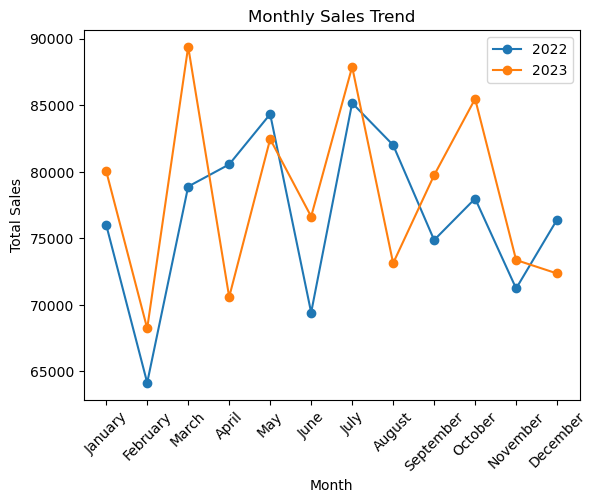

In [33]:
# Plot

import matplotlib.pyplot as plt

plt.figure()
for year in monthly_sales['Year'].unique():
    data = monthly_sales[monthly_sales['Year']== year]
    plt.plot(data['Month'], data['Sales'], marker='o', label=year)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()


#### Insights

**Overall Trend**: Sales remain relatively stable across both years, with no clear long-term upward or downward trend, indicating steady but limited growth.

While 2023 shows higher sales in several peak months compared to 2022, the improvement is inconsistent, suggesting uneven growth rather than sustained expansion

Sales exhibit clear seasonal fluctuations, with recurring peaks in March, July, and October, and noticeable declines in February and June

Monthly sales show significant variability, indicating demand instability and potential dependence on seasonal or promotional factors.


### Product Analysis

#### Which product categories perform best?

In [34]:
catagory_performance = sales_data.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending= False)
catagory_performance

,Sales,Profit
Category,,
Furniture,628102.55,-5505.10
Office Supplies,627279.74,47.18
Technology,604718.44,-2063.94


#### Insights

Despite generating high sales/revenue *Furniture* and *Technology* have a negative profit, while *Office Supplies* is the only category to generate positive profit. 

In [49]:
pivot = pd.pivot_table(
    sales_data,
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

pivot

Region,Asia,Europe,USA,Unknown
Category,,,,
Furniture,200289.52,202099.89,195259.16,30453.98
Office Supplies,191410.31,212277.96,192641.71,30949.76
Technology,187939.49,188663.67,196734.27,31381.01


In [51]:
pivot = pd.pivot_table(
    sales_data,
    values ='Profit',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

pivot

Region,Asia,Europe,USA,Unknown
Category,,,,
Furniture,-1435.44,-221.53,-2689.21,-1158.92
Office Supplies,258.63,219.40,-738.17,307.32
Technology,-102.71,-457.72,-1073.13,-430.38


#### Insights

Losses are primarily driven by **Furniture and Technology** in the **USA**, whereas **Office Supplies** in **Europe and Asia** consistently generate positive profit.

### Regional Analysis

#### Which regions drive the most revenue and profit

In [37]:
region_performance = sales_data.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
region_performance

,Sales,Profit
Region,,
Europe,603041.52,-459.85
USA,584635.14,-4500.51
Asia,579639.32,-1279.52
Unknown,92784.75,-1281.98


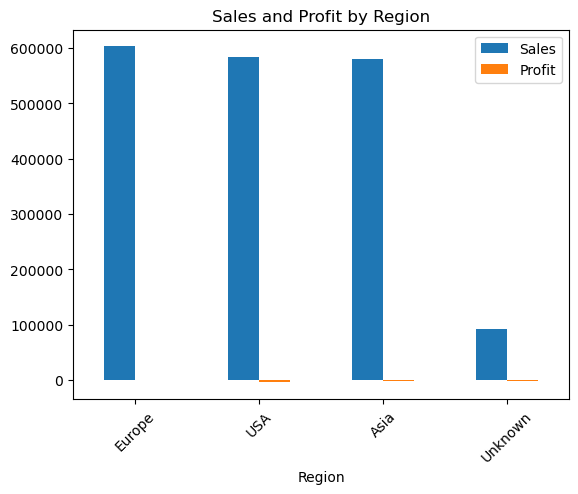

In [38]:
region_performance.plot(kind='bar')
plt.title("Sales and Profit by Region")
plt.xticks(rotation=45)
plt.show()

#### Insights

All regions operate at a loss, with the USA contributing the most significant losses despite strong revenue/sales performance, while Europe remains closest to profitability.

### Profitability

#### Are we actually making money?

In [40]:
sales_data['Profit_Margin'] = sales_data['Profit'] / sales_data['Sales']
sales_data.groupby('Category')['Profit_Margin'].mean()

Category
Furniture         -0.006851
Office Supplies    0.000196
Technology        -0.004714
Name: Profit_Margin, dtype: float64

In [41]:
sales_data.groupby('Region')['Profit_Margin'].mean().sort_values(ascending= False)

Region
Europe    -0.000428
Asia      -0.003811
USA       -0.006413
Unknown   -0.008977
Name: Profit_Margin, dtype: float64

#### Insights

Overall profitability is negative across most segments, indicating structural issues in pricing, cost management, or discount strategies.”

### Customer Analysis

customer_performance = (sales_data.groupby('CustomerID')[['Sales', 'Profit']].sum() )

customer_performance['Profit Margin']=(
    customer_performance['Profit']/ customer_performance['Sales']
)

customer_performance = customer_performance.sort_values(by ='Sales', ascending = False)

customer_performance.head(10)

#### Insights

High-revenue customers are not always profitable, suggesting inconsistent pricing or high servicing costs for certain customer segments.

### Recomendation

1. The absence of a strong growth trend combined with high seasonality suggests that the business relies heavily on periodic demand spikes rather than consistent revenue generation. The company should investigate the drivers behind peak months and replicate successful strategies

2. Conduct a detailed cost and pricing review for Furniture and Technology, particularly in the USA, where losses are most significant.

3. Increase focus on Office Supplies, especially in Europe and Asia, as these segments demonstrate consistent profitability

4. Investigate operational and pricing inefficiencies in the USA market, where strong sales performance is not translating into profitability.

5. Identify and reassess high-revenue but unprofitable customers to optimize pricing, discount strategies, and service costs

6. Implement stricter data validation rules (e.g., consistent region classification, complete customer records) to improve reporting accuracy and decision-making